# 22_因果机器学习-从 AIPW 到 DML：交互回归模型

## Notebook 使用说明

这是因果学习系列的第 13 份，也是“22. 因果机器学习”的第 3 份。建议先阅读“21. 因果推断基础”中的《08. 双重稳健估计与AIPW》，以及本章《02. 双重机器学习与部分线性模型》。需要 NumPy、pandas、Matplotlib、SciPy、scikit-learn 和 DoubleML：`python -m pip install numpy pandas matplotlib scipy scikit-learn doubleml==0.11.4`。

主线依据参考资料 [2] 第 9.3、9.4 节：在二元处理、效应可以随特征变化时，用交叉拟合的结果预测与评分构造 ATE、ATT 的正交得分。[1] 第 12、13 章用于对照 AIPW 与 ATT。本文的 $T$ 对应第二本书的 $D$，$e(X)$ 对应其 $m_0(X)$，$\mu_t(X)$ 对应其 $g_0(t,X)$。书中使用 ATET，软件参数写作 `ATTE`，本系列仍称 ATT。

三层总体表、非线性主模拟、重叠实验和两道练习均为另设的教学构造，不是原书 401(k) 实证结果的复现。二次特征、随机森林、索引检查和数值核对属于本篇实现；软件接口依据 [3–4]。本次核对使用 DoubleML 0.11.4，不依靠软件默认分折或默认权重来比较数值。

所有数据由代码生成，不读取外部文件，也不依赖前面 Notebook 的变量或辅助模块。默认使用 5 折交叉拟合，在 600 人和 2,400 人两种样本量下各做 300 次独立重复模拟；低重叠部分另做两种机制下各 500 次已知辅助函数模拟。代码输出和图形均已保存；重新运行请使用 Restart Kernel and Run All Cells，修改参数后以新的输出为准。

In [1]:
# 环境初始化：只生成模拟数据，不读写外部数据文件。
import os
import sys
import tempfile
import warnings
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
from numpy.polynomial.legendre import leggauss
import scipy
from scipy.special import expit
import sklearn
from sklearn.base import clone, is_classifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, brier_score_loss

# 只处理可选的交互式进度条提示，不屏蔽数值或模型收敛警告。
from tqdm import TqdmWarning
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)
    import doubleml as dml
    from doubleml.utils import PSProcessorConfig

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 12)
pd.set_option("display.width", 150)

X_COLS = [f"X{j}" for j in range(1, 6)]
SEED_DATA = 42
SEED_SPLIT = 2026
SEED_REPEAT = 2027
SEED_OVERLAP = 2028
SEED_BINARY = 2029
SEED_LEARNER = 99
N_MAIN = 2400
N_FOLDS = 5
N_REPEATS = 300
SAMPLE_SIZES = (600, 2400)
N_OVERLAP = 1600
N_OVERLAP_REPEATS = 500
CLIP = 0.01
ALPHA_CI = 0.05
Z_CRIT = NormalDist().inv_cdf(1-ALPHA_CI/2)

if N_REPEATS < 2 or N_OVERLAP_REPEATS < 2:
    raise ValueError("独立重复模拟至少需要两次。")
print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"SciPy {scipy.__version__} | scikit-learn {sklearn.__version__} | DoubleML {dml.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
SciPy 1.17.0 | scikit-learn 1.8.0 | DoubleML 0.11.4


上一篇把两侧残差放在一起，估计一个共同斜率。这次回到“接受或不接受处理”：培训对基础较弱的人可能作用更大，对另一些人作用较小。此时，“所有人的平均效应”和“已经接受培训者的平均效应”也不必相同。

先不要换学习器。我们需要先换清楚要估计的量，再决定把哪些预测放进哪个公式。第八份笔记中的 AIPW 正好提供了另一种正交得分；这次为它的每一项预测都安排一个没有见过该行的训练集。

## 理论基础

### 1. 交互回归模型允许什么变化？

二元处理 $T\in\{0,1\}$ 下，写成

$$
Y=\mu_T(X)+\varepsilon,\qquad E[\varepsilon\mid T,X]=0,
\qquad e(X)=P(T=1\mid X).
$$

交互回归模型（Interactive Regression Model，IRM）允许 $\mu_0(X)$ 与 $\mu_1(X)$ 是两个不同的函数，不要求二者只相差一个常数。这里的“交互”不意味着只能在一条线性回归里加入几个乘积项。[2，第 9.3 节]

定义条件均值差

$$
\tau(X)=\mu_1(X)-\mu_0(X).
$$

在处理定义明确、无干扰、一致性、给定处理前 $X$ 满足条件可忽略性，并有足够重叠时，它等于条件平均处理效应 $E[Y(1)-Y(0)\mid X]$。没有这些识别条件，观察数据中的均值差仍只是调整后的预测比较；原书称为 APE，而不是直接称为 ATE。[1，第 10、12 章；2，第 9.3 节]

本篇先估计两个总体平均量：

$$
\theta_A=E[\tau(X)],\qquad
\theta_T=E[\tau(X)\mid T=1]
=\frac{E[e(X)\tau(X)]}{p},\quad p=P(T=1).
$$

前者是 ATE，后者是 ATT。ATT 的识别只需未处理侧的条件可忽略性，以及接受者所在特征区域有可比较的对照；本例采用两侧条件，以便一起比较三个目标。[1，第 13.1 节；2，附录 5.C]

允许 $\tau(X)$ 变化，是为了不强加恒定效应；本篇尚不训练一个供新样本使用的 CATE 学习器，也不把两列预测之差当作已观测到的个体效应。

### 2. AIPW 的公式不变，预测的来源变了

将样本分为 $K$ 折。对第 $k$ 折中的人，使用其余折估计评分 $\widehat e^{(-k)}$；结果模型也只用其余折，且分别在其中的对照、处理样本中拟合 $\widehat\mu_0^{(-k)}$ 与 $\widehat\mu_1^{(-k)}$。这两条结果曲线都要预测留出折的所有人。

为缩短公式，下面省略 $(-k)$，但代码始终保留折外预测。构造

$$
\widehat\Gamma_i=
\widehat\mu_1(X_i)-\widehat\mu_0(X_i)
+\frac{T_i}{\widehat e_i}\{Y_i-\widehat\mu_1(X_i)\}
-\frac{1-T_i}{1-\widehat e_i}\{Y_i-\widehat\mu_0(X_i)\}.
$$

随后计算

$$
\widehat\theta_A=\frac1n\sum_i\widehat\Gamma_i,
\qquad \widehat\psi_{Ai}=\widehat\Gamma_i-\widehat\theta_A,
\qquad
\widehat{\mathrm{SE}}_A=
\sqrt{\frac{1}{n^2}\sum_i\widehat\psi_{Ai}^2}.
$$

这就是 [2] 第 9.3 节的 ATE 算法。与第八份相比，没有给 AIPW 再套一个新“因果模型”；变化在于辅助函数的学习方式、交叉拟合，以及正交得分下的推断条件。

### 3. 双重稳健与 DML 区间不是同一句保证

把已经在训练集学好的函数暂时视为固定，记 $a_t=\widehat\mu_t-\mu_t$、$b=\widehat e-e$。由 [1] 第 12.1 节的偏差分解，可直接得到

$$
E[\widehat\Gamma]-\theta_A
=E\left[b(X)\left\{\frac{a_1(X)}{\widehat e(X)}
+\frac{a_0(X)}{1-\widehat e(X)}\right\}\right].
$$

评分正确，或两侧结果均值都正确，右侧就消失；两边都只是近似正确时，偏差涉及误差乘积。在评分远离 0、1 时，这也解释了为何局部一阶扰动被消掉。

但常规 DML 正态区间还要求辅助误差足够小。原书定理 9.3.1 的一个条件是：两类误差都趋于零，而且它们的乘积是 $o_p(n^{-1/2})$，再加重叠与其他正则条件。两类各自达到 $o_p(n^{-1/4})$ 是一种充分情形，不是唯一情形。[2，定理 9.3.1]

所以，“一类模型写对便能一致估计”不能直接改写成“另一类可以一直错，但把伪结局标准差除以 $\sqrt n$ 就一定得到正确标准误”。交叉拟合也不让所有得分在有限样本中变成独立观测；上面的方差公式依靠相应的渐近展开。

## 完整案例一：同一个总体，三种平均

### 1. 全体、接受者，以及残差回归所强调的人

先用三类人组成一张可以手算的总体表。表中的比例、处理概率与条件效应都是指定的总体量，不是一次抽样得到的估计值。

ATE 用原来的人群比例平均；ATT 将比例乘以 $e(X)$ 后重新归一化。上一份的 PLR 残差回归在这里又会给出什么？

由 $\ell(X)=\mu_0(X)+e(X)\tau(X)$，可得

$$
Y-\ell(X)=\{T-e(X)\}\tau(X)+\varepsilon.
$$

两侧乘以 $T-e(X)$ 并取期望，得到

$$
\theta_{\mathrm{PLR}}
=\frac{E[e(X)\{1-e(X)\}\tau(X)]}
{E[e(X)\{1-e(X)\}]}.
$$

它更强调处理概率接近一半、两种处理都较常见的人，而不是对全体人等权平均。这正是 [2] 备注 9.3.3 的重叠加权解释。

<details>
<summary>附件中的一处符号核对</summary>

附件正文第 256 页（PDF 第 266 页）备注 9.3.3，在展开 $g_0(D,X)$ 的第一行写成了 $g_0(0,X)+D\{g_0(0,X)-g_0(1,X)\}$。代入 $D=1$ 即可看出差的顺序不对。本篇明确采用 $g_0(0,X)+D\{g_0(1,X)-g_0(0,X)\}$；该备注后面的残差表达式与最终重叠权重公式沿用原书。这不是另换一个定义。

</details>

,类别,总体比例,处理概率,mu0,条件效应,mu1,ATE权重,ATT权重,PLR权重
0,A,0.4,0.2,2.0,0.5,2.5,0.4,0.16,0.3855
1,B,0.3,0.5,3.0,1.0,4.0,0.3,0.30,0.4518
2,C,0.3,0.9,4.0,3.0,7.0,0.3,0.54,0.1627


,总体目标
ATE,1.4000
ATT,2.0000
PLR,1.1325


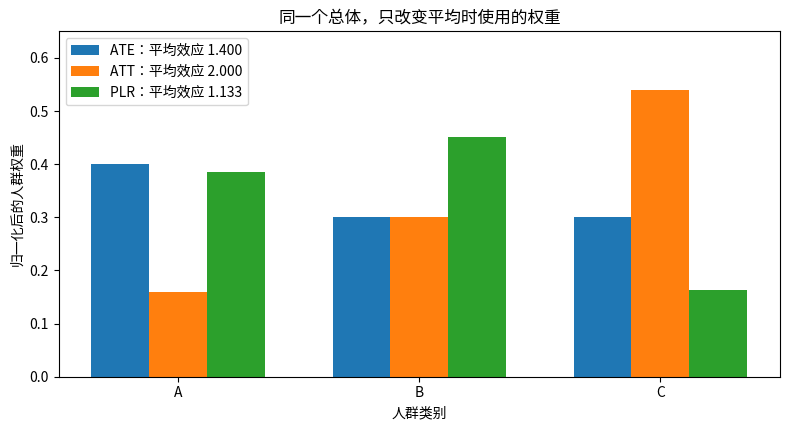

In [2]:
population = pd.DataFrame({
    "类别": ["A", "B", "C"],
    "总体比例": [.4, .3, .3],
    "处理概率": [.2, .5, .9],
    "mu0": [2., 3., 4.],
    "条件效应": [.5, 1., 3.],
})
population["mu1"] = population["mu0"]+population["条件效应"]
population["ATE权重"] = population["总体比例"]
population["ATT权重"] = population["总体比例"]*population["处理概率"]
population["PLR权重"] = (population["总体比例"]*population["处理概率"]
                          *(1-population["处理概率"]))
for name in ["ATE权重", "ATT权重", "PLR权重"]:
    population[name] /= population[name].sum()
display(population.round(4))

toy_targets = {name: float(population[f"{name}权重"] @ population["条件效应"])
               for name in ["ATE", "ATT", "PLR"]}
display(pd.DataFrame({"总体目标": toy_targets}).round(4))
assert np.isclose(toy_targets["ATE"], 1.4)
assert np.isclose(toy_targets["ATT"], 2.0)

fig, ax = plt.subplots(figsize=(8, 4.4))
positions = np.arange(len(population))
for j, name in enumerate(["ATE", "ATT", "PLR"]):
    ax.bar(positions+(j-1)*.24, population[f"{name}权重"], width=.24,
           label=f"{name}：平均效应 {toy_targets[name]:.3f}")
ax.set(xticks=positions, xticklabels=population["类别"],
       xlabel="人群类别", ylabel="归一化后的人群权重", ylim=(0, .65),
       title="同一个总体，只改变平均时使用的权重")
ax.legend()
fig.tight_layout()
plt.show()

C 类人的效应较大，也更容易接受处理，因此 ATT 较大。PLR 则降低了处理概率为 0.9 的 C 类人的比重。三个答案不同，并不意味着其中两个算法算错了。

如果条件效应恒定，三种平均才必然相同；如果处理概率恒定，三套人群权重也相同。这里说的是总体等式，不是任意一次样本中三个估计值必须完全一致。

## 完整案例二：从三列折外预测开始

### 1. 构造非线性结局与异质性效应

五个处理前变量独立服从 $U(-1,1)$。设

$$
e(X)=\operatorname{expit}(0.8+2X_1+0.6X_2),
$$

$$
\mu_0(X)=2+1.4X_1+X_2^2+0.8X_1X_2+0.5X_3,
$$

$$
\tau(X)=1+1.8X_1+2.4(X_1^2-1/3)+0.5X_2X_3,
\qquad \mu_1(X)=\mu_0(X)+\tau(X).
$$

处理按 $e(X)$ 生成；两个潜在结局分别加上独立的零均值噪声，其标准差可以随 $X$ 改变。处理分配不使用这些结局噪声，因此给定 $X$ 的可忽略性由这个教学生成过程保证。真实个体效应还含两份噪声之差，不必等于条件均值差 $\tau(X)$。

由 $E[X_1]=E[X_2X_3]=0$、$E[X_1^2]=1/3$，总体 ATE 恰好为 1。ATT 与 PLR 目标用确定性数值积分计算；它们只用于检查，不会送进模型训练。`observed` 只保存实际可见的 $X,T,Y$，`truth` 单独保存辅助函数真值。

In [3]:
def true_functions(x: np.ndarray, overlap_scale: float = 1.0) -> dict:
    x = np.asarray(x, dtype=float)
    x1, x2, x3 = x[:, 0], x[:, 1], x[:, 2]
    e = expit(.8 + overlap_scale * (2*x1 + .6*x2))
    mu0 = 2 + 1.4*x1 + x2**2 + .8*x1*x2 + .5*x3
    tau = 1 + 1.8*x1 + 2.4*(x1**2-1/3) + .5*x2*x3
    return {'e': e, 'mu0': mu0, 'mu1': mu0+tau, 'tau': tau,
            'ell': mu0+e*tau}

def make_irm_data(n: int, seed: int, overlap_scale: float = 1.0) -> tuple:
    if not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError('样本量 n 必须是至少 20 的整数。')
    if not np.isfinite(overlap_scale) or overlap_scale <= 0:
        raise ValueError('overlap_scale 必须为正数。')
    rng = np.random.default_rng(seed)
    x = rng.uniform(-1, 1, size=(n, len(X_COLS)))
    truth = true_functions(x, overlap_scale)
    t = rng.binomial(1, truth['e'])
    noise = rng.normal(size=(n, 2))
    y0 = truth['mu0']+(1+.25*np.abs(x[:, 0]))*noise[:, 0]
    y1 = truth['mu1']+(1+.4*np.abs(x[:, 1]))*noise[:, 1]
    obs = pd.DataFrame(x, columns=X_COLS)
    obs['T'], obs['Y'] = t, np.where(t == 1, y1, y0)
    return obs, truth

def population_targets(overlap_scale: float = 1.0, order: int = 80) -> dict:
    # X3 的条件均值为 0，故可将有关 X3 的项先积分掉。
    nodes, weights = leggauss(order)
    x1, x2 = np.meshgrid(nodes, nodes, indexing='ij')
    w = weights[:, None]*weights[None, :]/4
    e = expit(.8+overlap_scale*(2*x1+.6*x2))
    tau = 1+1.8*x1+2.4*(x1**2-1/3)
    p = np.sum(w*e)
    return {'ATE': 1.0, 'ATT': float(np.sum(w*e*tau)/p),
            'PLR': float(np.sum(w*e*(1-e)*tau)/np.sum(w*e*(1-e))),
            'P(T=1)': float(p)}

observed, truth = make_irm_data(N_MAIN, SEED_DATA)
pop_targets = population_targets()
# 提高积分阶数再核对，避免把积分误差误认成估计误差。
for name in ["ATE", "ATT", "PLR", "P(T=1)"]:
    np.testing.assert_allclose(pop_targets[name], population_targets(order=120)[name], atol=1e-10)
display(observed.head(8).round(4))
display(observed.groupby("T")["Y"].agg(["size", "mean", "std"]).round(4))
display(pd.DataFrame({"总体目标": {k: pop_targets[k] for k in ["ATE", "ATT", "PLR"]}}).round(6))
print(f"总体接受处理比例：{pop_targets['P(T=1)']:.4f}")
print(f"本次样本接受处理比例：{observed['T'].mean():.4f}")

,X1,X2,X3,X4,X5,T,Y
0,0.5479,-0.1222,0.7172,0.3947,-0.8116,1,5.4539
1,0.9512,0.5223,0.5721,-0.7438,-0.0992,1,10.5016
2,-0.2584,0.8535,0.2877,0.6455,-0.1132,1,2.2082
3,-0.5455,0.1092,-0.8724,0.6553,0.2633,1,0.6998
4,0.5162,-0.2909,0.9414,0.7862,0.5568,1,6.2367
5,-0.6107,-0.0666,-0.9124,-0.6914,0.3661,0,-0.3094
6,0.4895,0.9350,-0.3483,-0.2591,-0.0609,1,5.6696
7,-0.6211,-0.7402,-0.0486,-0.5462,0.3396,1,-0.1637


,size,mean,std
T,,,
0,855,1.8675,1.3741
1,1545,3.9115,2.4830


,总体目标
ATE,1.000000
ATT,1.316248
PLR,0.581403


总体接受处理比例：0.6471
本次样本接受处理比例：0.6438


### 2. 分折后，结果模型还要按处理状态拆开

一次 5 折交叉拟合并不是让三个模型都训练同样多的人。评分使用外层训练折的全部人；$\mu_0$ 只能用其中的对照结局，$\mu_1$ 只能用其中的处理结局。留出折的任何结局都不进入这三次拟合。

下面按 $T$ 分层划分，避免小组在某一折完全缺失。分层只是改善折内人数安排，并不是对原研究重新做随机分组。检查函数同时防止训练与留出重叠、漏行、重复预测和单类训练集。

In [4]:
def check_data(data: pd.DataFrame) -> tuple:
    x = data[X_COLS].to_numpy(dtype=float)
    t = data['T'].to_numpy(dtype=float)
    y = data['Y'].to_numpy(dtype=float)
    if len(data) < 4 or not np.isfinite(np.c_[x, t, y]).all():
        raise ValueError('数据必须有限且至少有 4 行。')
    if not np.array_equal(np.unique(t), [0., 1.]):
        raise ValueError('T 必须同时包含 0 和 1。')
    return x, t, y

def make_splits(t: np.ndarray, k: int = N_FOLDS, seed: int = SEED_SPLIT) -> list:
    t = np.asarray(t)
    if t.ndim != 1 or not np.array_equal(np.unique(t), [0, 1]):
        raise ValueError('分折需要同时包含 0、1 的一维处理变量。')
    if not isinstance(k, (int, np.integer)) or not 2 <= k <= np.min(np.bincount(t.astype(int))):
        raise ValueError('折数至少为 2，且不得超过较小处理组的人数。')
    return list(StratifiedKFold(n_splits=int(k), shuffle=True,
                random_state=seed).split(np.zeros(len(t)), t))

def validate_splits(splits: list, n: int, t: np.ndarray) -> list:
    if len(splits) < 2:
        raise ValueError('交叉拟合至少需要两折。')
    seen = np.zeros(n, dtype=int)
    checked = []
    for tr, te in splits:
        tr, te = np.asarray(tr), np.asarray(te)
        for idx in (tr, te):
            if (idx.ndim != 1 or not np.issubdtype(idx.dtype, np.integer)
                or len(idx) == 0 or len(np.unique(idx)) != len(idx)):
                raise ValueError('索引必须是非空、不重复的一维整数数组。')
            if idx.min() < 0 or idx.max() >= n:
                raise ValueError('分折索引越界。')
        if np.intersect1d(tr, te).size or len(tr)+len(te) != n:
            raise ValueError('每折训练和留出必须互不相交且互补。')
        if not np.array_equal(np.unique(t[tr]), [0, 1]):
            raise ValueError('每个训练折都需要两种处理状态。')
        seen[te] += 1
        checked.append((tr.copy(), te.copy()))
    if not np.all(seen == 1):
        raise ValueError('每一行必须恰好被留出一次。')
    return checked

x, t, y = check_data(observed)
splits = make_splits(t)
checked_splits = validate_splits(splits, len(observed), t)
train_first, test_first = checked_splits[0]
print("第一折训练行（前 12 个，显示从 1 开始）：", (train_first[:12]+1).tolist())
print("第一折留出行（前 12 个，显示从 1 开始）：", (test_first[:12]+1).tolist())
print("第一折训练中的两组人数：", np.bincount(t[train_first].astype(int)).tolist())

第一折训练行（前 12 个，显示从 1 开始）： [1, 2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14]
第一折留出行（前 12 个，显示从 1 开始）： [4, 10, 21, 29, 36, 40, 41, 43, 49, 53, 66, 68]
第一折训练中的两组人数： [684, 1236]


### 3. 先用二次特征，再换成随机森林

主实现将二次特征、标准化与 Ridge 放在同一个 `Pipeline` 中。这个例子的真实结果均值恰好包含在二次特征中；固定的 Ridge 惩罚用于稳定有限样本拟合，不是因为预先知道效应数值而调出来的。评分用 Logistic 回归，输出的是 `predict_proba` 的处理概率，不是 `predict` 的 0/1 标签。

随机森林作为另一种辅助学习器，使用固定参数作对照，不以效应是否显著或是否接近 1 来挑参数。需要调参时，应像上一篇一样把内层选择放进外层训练折。

下面直接展开交叉拟合循环。`clone` 让各折、各处理组分别得到自己的模型；两条结果曲线都预测整个留出折，评分也按原始行号放回。

In [5]:
def make_learners(kind: str = 'quadratic') -> tuple:
    if kind in ('quadratic', 'linear'):
        transforms = [PolynomialFeatures(degree=2, include_bias=False)] if kind == 'quadratic' else []
        ml_g = make_pipeline(*transforms, StandardScaler(), Ridge(alpha=1.0))
        ml_m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0,
                    solver='lbfgs', max_iter=1000, tol=1e-8))
    elif kind == 'forest':
        ml_g = RandomForestRegressor(n_estimators=100, min_samples_leaf=12,
                    max_features=1.0, n_jobs=1, random_state=SEED_LEARNER)
        ml_m = RandomForestClassifier(n_estimators=100, min_samples_leaf=20,
                    max_features=1.0, n_jobs=1, random_state=SEED_LEARNER)
    else:
        raise ValueError('kind 应为 quadratic、linear 或 forest。')
    return ml_g, ml_m

def predict_mean(model, x: np.ndarray) -> np.ndarray:
    if is_classifier(model):
        classes = np.asarray(model.classes_)
        if not np.array_equal(classes, [0, 1]):
            raise ValueError('二元分类器的类别必须为 0、1。')
        result = model.predict_proba(x)[:, np.flatnonzero(classes == 1)[0]]
    else:
        result = model.predict(x)
    result = np.asarray(result, dtype=float)
    if result.shape != (len(x),) or not np.isfinite(result).all():
        raise ValueError('预测必须是与样本对齐的一维有限数组。')
    return result

def crossfit_irm(data: pd.DataFrame, ml_g, ml_m, splits: list,
                 clip: float = CLIP, store_models: bool = False) -> dict:
    x, t, y = check_data(data)
    if not is_classifier(ml_m):
        raise TypeError('倾向评分需要能输出概率的分类器，不使用硬分类标签。')
    if not np.isfinite(clip) or not 0 < clip < .5:
        raise ValueError('评分截断阈值必须在 (0, .5) 内。')
    splits = validate_splits(splits, len(data), t)
    pred = {key: np.full(len(data), np.nan) for key in ['mu0', 'mu1', 'e_raw']}
    fold_id = np.full(len(data), -1, dtype=int)
    audit, models = [], []
    for fold, (train, test) in enumerate(splits):
        train0, train1 = train[t[train] == 0], train[t[train] == 1]
        g0 = clone(ml_g).fit(x[train0], y[train0])
        g1 = clone(ml_g).fit(x[train1], y[train1])
        m = clone(ml_m).fit(x[train], t[train])
        pred['mu0'][test] = predict_mean(g0, x[test])
        pred['mu1'][test] = predict_mean(g1, x[test])
        pred['e_raw'][test] = predict_mean(m, x[test])
        fold_id[test] = fold
        audit.append({'折': fold+1, '训练0': len(train0), '训练1': len(train1),
                      '留出0': int(np.sum(t[test] == 0)), '留出1': int(np.sum(t[test] == 1)),
                      '训练与留出交集': len(np.intersect1d(train, test))})
        if store_models:
            models.append((g0, g1, m))
    if not all(np.isfinite(v).all() for v in pred.values()):
        raise RuntimeError('存在未填写或非有限的折外预测。')
    pred['e'] = np.clip(pred['e_raw'], clip, 1-clip)
    pred['fold'] = fold_id
    pred['audit'] = pd.DataFrame(audit)
    pred['n_clipped'] = int(np.sum(pred['e'] != pred['e_raw']))
    pred['models'] = models
    return pred

ml_g, ml_m = make_learners("quadratic")
oof = crossfit_irm(observed, ml_g, ml_m, splits, store_models=True)
display(oof["audit"])
prediction_table = observed[["T", "Y"]].copy()
prediction_table["折"] = oof["fold"]+1
prediction_table["mu0_OOF"] = oof["mu0"]
prediction_table["mu1_OOF"] = oof["mu1"]
prediction_table["e_OOF"] = oof["e"]
display(prediction_table.head(10).round(4))
print(f"主模型发生评分截断的行数：{oof['n_clipped']} / {len(observed)}")

,折,训练0,训练1,留出0,留出1,训练与留出交集
0,1,684,1236,171,309,0
1,2,684,1236,171,309,0
2,3,684,1236,171,309,0
3,4,684,1236,171,309,0
4,5,684,1236,171,309,0


,T,Y,折,mu0_OOF,mu1_OOF,e_OOF
0,1,5.4539,3,3.4104,5.1637,0.8571
1,1,10.5016,2,4.2649,8.6943,0.9586
2,1,2.2082,3,2.7266,2.3668,0.7101
3,1,0.6998,1,0.7285,0.8772,0.4746
4,1,6.2367,2,2.9818,4.7762,0.8473
5,0,-0.3094,4,0.5394,0.8911,0.3837
6,1,5.6696,3,3.7366,5.1525,0.9235
7,1,-0.1637,2,2.2074,2.1265,0.2770
8,0,0.0584,2,2.2107,2.5706,0.7491
9,1,4.1824,1,2.5933,4.7962,0.8766


主模型发生评分截断的行数：0 / 2400


### 4. 同样的预测，构造 ATE 与 ATT 的不同得分

ATE 对所有人的预测差取平均，再用两侧残差纠偏。ATT 则只需要补上接受者的未处理结局，因此不需要 $\mu_1$：

$$
Z_i=T_i\{Y_i-\widehat\mu_0(X_i)\}
-(1-T_i)\frac{\widehat e_i}{1-\widehat e_i}\{Y_i-\widehat\mu_0(X_i)\},
\qquad
\widehat\theta_T=\frac{\sum_i Z_i}{\sum_i T_i}.
$$

这个 $Z_i$ 只是本节的计算记号，不是工具变量。对应得分和影响函数估计为

$$
\widehat\psi_{Ti}=\frac{Z_i-T_i\widehat\theta_T}{\widehat p},
\qquad \widehat p=\frac1n\sum_iT_i,
\qquad
\widehat{\mathrm{SE}}_T=
\sqrt{\frac{1}{n^2}\sum_i\widehat\psi_{Ti}^2}.
$$

分母 $\widehat p$ 来自同一份随机样本，不能把 $Z_i/\widehat p$ 当作普通伪结局、减去一个共同常数就结束；中心项是 $T_i\widehat\theta_T/\widehat p$。对照也会通过纠偏项影响 ATT 的不确定性。[1，第 13.2 节；2，式 (9.4.8)]

为统一计算，将得分写成 $\psi_i=a_i\theta+b_i$。解为 $\widehat\theta=-\overline b/\overline a$，影响函数估计为 $-\widehat\psi_i/\overline a$。本篇明确使用“加号”约定，与 DoubleML 的 `psi_a`、`psi_b` 对应；原书备注 9.4.3 以 $\psi^b-\psi^a\theta$ 记号书写，不能不换符号就代入。[2，第 9.4 节；4]

PLR 对照从同一套折外函数构造 $\widehat\ell=(1-\widehat e)\widehat\mu_0+\widehat e\widehat\mu_1$，然后使用上一份的残差回归公式。这里是为了固定预测来源、只比较得分与目标；并不是另行拟合了一个 `Y ~ X` 模型。

In [6]:
def linear_score(a: np.ndarray, b: np.ndarray) -> dict:
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if a.ndim != 1 or b.shape != a.shape or len(a) < 2 or not np.isfinite(np.c_[a, b]).all():
        raise ValueError('a、b 必须是等长的一维有限数组，且至少有两行。')
    jacobian = float(a.mean())
    if abs(jacobian) <= 1e-12:
        raise ValueError('平均得分导数接近零，不能稳定求解。')
    estimate = float(-b.mean()/jacobian)
    psi = a*estimate+b
    influence = -psi/jacobian
    se = float(np.sqrt(np.mean(influence**2)/len(a)))
    return {'estimate': estimate, 'se': se, 'lower': estimate-Z_CRIT*se,
            'upper': estimate+Z_CRIT*se, 'psi': psi, 'influence': influence,
            'a': a, 'b': b, 'jacobian': jacobian}

def scores_from_predictions(y, t, mu0, mu1, e) -> dict:
    y, t, mu0, mu1, e = [np.asarray(v, dtype=float) for v in (y, t, mu0, mu1, e)]
    if y.ndim != 1 or any(v.shape != y.shape for v in (t, mu0, mu1, e)):
        raise ValueError('所有输入必须是一维且等长。')
    if not np.isfinite(np.c_[y, t, mu0, mu1, e]).all():
        raise ValueError('输入不能有缺失或无限值。')
    if not np.array_equal(np.unique(t), [0., 1.]):
        raise ValueError('处理变量必须同时包含 0、1。')
    if np.any((e <= 0) | (e >= 1)):
        raise ValueError('评分必须严格处于 (0, 1)，不能传入 .predict 的类别标签。')
    gamma = mu1-mu0+t/e*(y-mu1)-(1-t)/(1-e)*(y-mu0)
    p = t.mean()
    z_att = t*(y-mu0)-(1-t)*e/(1-e)*(y-mu0)
    ell = (1-e)*mu0+e*mu1
    v = t-e
    return {'ATE': linear_score(-np.ones(len(y)), gamma),
            'ATT': linear_score(-t/p, z_att/p),
            'PLR': linear_score(-v**2, v*(y-ell))}

fitted_results = scores_from_predictions(y, t, oof["mu0"], oof["mu1"], oof["e"])
oracle_results = scores_from_predictions(y, t, truth["mu0"], truth["mu1"], truth["e"])

components = pd.DataFrame({
    "T": t, "预测差": oof["mu1"]-oof["mu0"],
    "处理侧纠偏": t/oof["e"]*(y-oof["mu1"]),
    "对照侧待减项": (1-t)/(1-oof["e"])*(y-oof["mu0"]),
})
components["Gamma_ATE"] = (components["预测差"]+components["处理侧纠偏"]
                           -components["对照侧待减项"])
components["ATT得分"] = fitted_results["ATT"]["psi"]
display(components.head(10).round(4))
display(components[["预测差", "处理侧纠偏", "对照侧待减项", "Gamma_ATE"]].mean().to_frame("样本平均").round(5))

for name, result in fitted_results.items():
    np.testing.assert_allclose(result["psi"].mean(), 0., atol=1e-12)
np.testing.assert_allclose(components["Gamma_ATE"].mean(), fitted_results["ATE"]["estimate"])
print("ATE、ATT、PLR 的样本平均得分均为 0（数值容差内）。")

,T,预测差,处理侧纠偏,对照侧待减项,Gamma_ATE,ATT得分
0,1.0,1.7533,0.3386,0.0000,2.0919,1.1043
1,1.0,4.4294,1.8855,0.0000,6.3149,7.6181
2,1.0,-0.3597,-0.2235,-0.0000,-0.5832,-2.8753
3,1.0,0.1487,-0.3737,-0.0000,-0.2250,-2.1145
4,1.0,1.7944,1.7238,0.0000,3.5182,2.9862
5,0.0,0.3517,-0.0000,-1.3774,1.7291,0.8210
6,1.0,1.4159,0.5599,0.0000,1.9758,0.9326
7,1.0,-0.0809,-8.2690,-0.0000,-8.3499,-5.7533
8,0.0,0.3599,-0.0000,-8.5784,8.9383,9.9823
9,1.0,2.2028,-0.7002,0.0000,1.5026,0.3984


,样本平均
预测差,0.99726
处理侧纠偏,0.00408
对照侧待减项,0.01385
Gamma_ATE,0.98750


ATE、ATT、PLR 的样本平均得分均为 0（数值容差内）。


表里的“纠偏”可以为正，也可以为负。它不是在每个人身上恢复了真实的缺失结局；它是利用有观测的一侧的残差，纠正目标人群的平均预测。

ATE 的平均预测差与 AIPW 估计也不要求在有限样本里相同。组内 OLS 的训练残差和为零，不意味着折外加权残差和为零。

### 5. 检查评分、平衡与有效样本量

先看评分分布，再检查加权后的协变量平衡。ATE 使用 $T/e$ 与 $(1-T)/(1-e)$；ATT 保留接受者权重为 1，对照权重为 $e/(1-e)$。两套权重对应不同的人群目标。

SMD 分母固定为调整前两组方差平均值的平方根，避免权重改变后分母也随之变化。对二次项和交互项也做检查，不只看原始变量的均值。有效样本量 $\mathrm{ESS}=(\sum w)^2/\sum w^2$ 用于描述权重集中程度，不拿它替代得分方差里的样本量 $n$。

,对照组OOF_RMSE,处理组OOF_RMSE,评分Brier,原始评分最小,原始评分最大,截断行数
辅助模型,,,,,,
二次特征 / Logit,1.1256,1.2117,0.1739,0.1273,0.9715,0
随机森林,1.1336,1.2449,0.1801,0.0956,0.9914,3


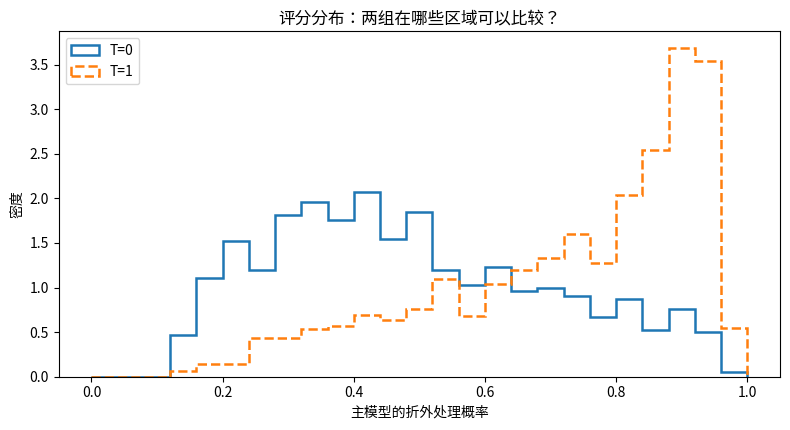

In [7]:
forest_oof = crossfit_irm(observed, *make_learners("forest"), splits)
forest_results = scores_from_predictions(y, t, forest_oof["mu0"], forest_oof["mu1"], forest_oof["e"])

prediction_checks = []
for label, pr in [("二次特征 / Logit", oof), ("随机森林", forest_oof)]:
    prediction_checks.append({
        "辅助模型": label,
        "对照组OOF_RMSE": np.sqrt(mean_squared_error(y[t == 0], pr["mu0"][t == 0])),
        "处理组OOF_RMSE": np.sqrt(mean_squared_error(y[t == 1], pr["mu1"][t == 1])),
        "评分Brier": brier_score_loss(t, pr["e_raw"]),
        "原始评分最小": pr["e_raw"].min(), "原始评分最大": pr["e_raw"].max(),
        "截断行数": pr["n_clipped"],
    })
display(pd.DataFrame(prediction_checks).set_index("辅助模型").round(4))

fig, ax = plt.subplots(figsize=(8, 4.4))
bins = np.linspace(0, 1, 26)
for state, linestyle in [(0, "-"), (1, "--")]:
    ax.hist(oof["e_raw"][t == state], bins=bins, density=True, histtype="step",
            linewidth=1.8, linestyle=linestyle, label=f"T={state}")
ax.set(xlabel="主模型的折外处理概率", ylabel="密度", title="评分分布：两组在哪些区域可以比较？")
ax.legend()
fig.tight_layout()
plt.show()

结果模型的 RMSE 只在对应处理组的留出结局上计算。对照的 $Y(1)$ 没有被观察，不能拿它做真实数据中的验证标签；本篇虽然能查看模拟真值，也不把它送进模型选择。评分 Brier 用于检查概率预测误差，不代表已经验证了无未测混杂。

下面的权重只是诊断工具。AIPW 还使用结果模型，因此不能把 AIPW 完全理解为一份加权后的数据；平衡改善也不等于两类辅助误差已经达到理论要求的速率。

,处理ESS,对照ESS,处理最大权重,对照最大权重,最大绝对SMD
方案,,,,,
未调整,1545.000,855.000,1.000,1.000,1.106
ATE权重,1252.272,407.073,7.858,27.999,0.053
ATT权重,1545.000,237.138,1.000,26.999,0.086


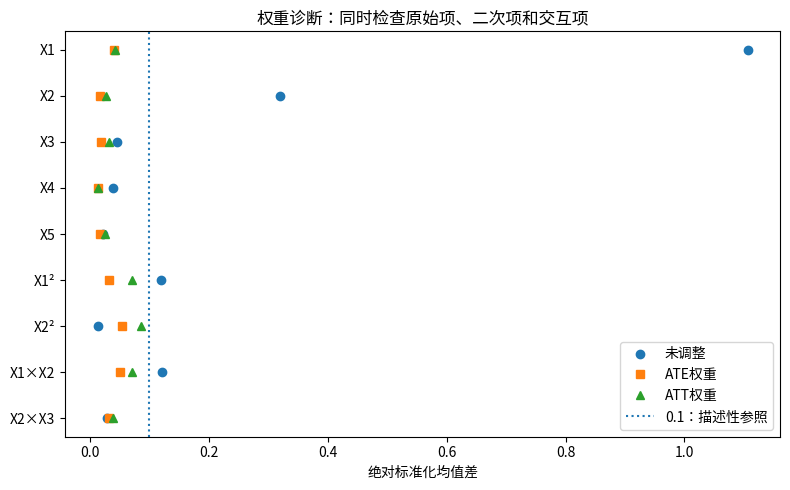

In [8]:
def effective_n(w: np.ndarray) -> float:
    w = np.asarray(w, dtype=float)
    if w.ndim != 1 or not np.isfinite(w).all() or np.any(w < 0) or w.sum() <= 0:
        raise ValueError("权重须为一维非负有限数组，且总和为正。")
    return float(w.sum()**2 / np.dot(w, w))


def smd_table(features: pd.DataFrame, t: np.ndarray, schemes: dict) -> pd.DataFrame:
    matrix = features.to_numpy(dtype=float)
    denominator = np.sqrt((matrix[t == 1].var(axis=0, ddof=1)
                           + matrix[t == 0].var(axis=0, ddof=1))/2)
    if np.any(denominator <= 0):
        raise ValueError("有变量的参考标准差为零。")
    result = {}
    for label, (w1, w0) in schemes.items():
        result[label] = (np.average(matrix, axis=0, weights=w1)
                         - np.average(matrix, axis=0, weights=w0))/denominator
    return pd.DataFrame(result, index=features.columns)


balance_features = observed[X_COLS].copy()
balance_features["X1²"] = x[:, 0]**2
balance_features["X2²"] = x[:, 1]**2
balance_features["X1×X2"] = x[:, 0]*x[:, 1]
balance_features["X2×X3"] = x[:, 1]*x[:, 2]
e_hat = oof["e"]
weight_schemes = {
    "未调整": (t, 1-t),
    "ATE权重": (t/e_hat, (1-t)/(1-e_hat)),
    "ATT权重": (t, (1-t)*e_hat/(1-e_hat)),
}
balance = smd_table(balance_features, t, weight_schemes)
ess_rows = []
for label, (w1, w0) in weight_schemes.items():
    ess_rows.append({"方案": label, "处理ESS": effective_n(w1), "对照ESS": effective_n(w0),
                     "处理最大权重": w1.max(), "对照最大权重": w0.max(),
                     "最大绝对SMD": balance[label].abs().max()})
display(pd.DataFrame(ess_rows).set_index("方案").round(3))

fig, ax = plt.subplots(figsize=(8, 5))
for label, marker in [("未调整", "o"), ("ATE权重", "s"), ("ATT权重", "^")]:
    ax.plot(balance[label].abs(), np.arange(len(balance)), marker=marker,
            linestyle="none", label=label)
ax.axvline(.1, linestyle=":", label="0.1：描述性参照")
ax.set(yticks=np.arange(len(balance)), yticklabels=balance.index,
       xlabel="绝对标准化均值差", title="权重诊断：同时检查原始项、二次项和交互项")
ax.invert_yaxis()
ax.legend()
fig.tight_layout()
plt.show()

### 6. 把三个目标分开报告

下面同时列出已知辅助函数的参考计算、二次特征交叉拟合，以及随机森林交叉拟合。参考计算也使用本次实际观察到的结局，因此仍有抽样误差；“已知辅助函数”不等于“没有噪声的答案”。

图中的竖线分别属于三个不同目标。若 PLR 靠近自己的参照而不靠近 ATE，不能把这段差距都叫作估计偏差。学习器不同而目标相同的比较，才主要反映拟合误差、有限样本噪声及正则化的影响。

,目标,辅助模型,估计,标准误,下限,上限,对应总体值
0,ATE,已知辅助函数,1.0074,0.0663,0.8774,1.1375,1.0000
1,ATE,二次特征 / Logit,0.9875,0.0679,0.8545,1.1205,1.0000
2,ATE,随机森林,0.9547,0.1002,0.7582,1.1511,1.0000
3,ATT,已知辅助函数,1.3619,0.0804,1.2044,1.5194,1.3162
4,ATT,二次特征 / Logit,1.3326,0.0842,1.1676,1.4975,1.3162
5,ATT,随机森林,1.2683,0.1399,0.9941,1.5424,1.3162
6,PLR,已知辅助函数,0.5528,0.0682,0.4191,0.6864,0.5814
7,PLR,二次特征 / Logit,0.5558,0.0689,0.4207,0.6908,0.5814
8,PLR,随机森林,0.5589,0.0683,0.4250,0.6928,0.5814


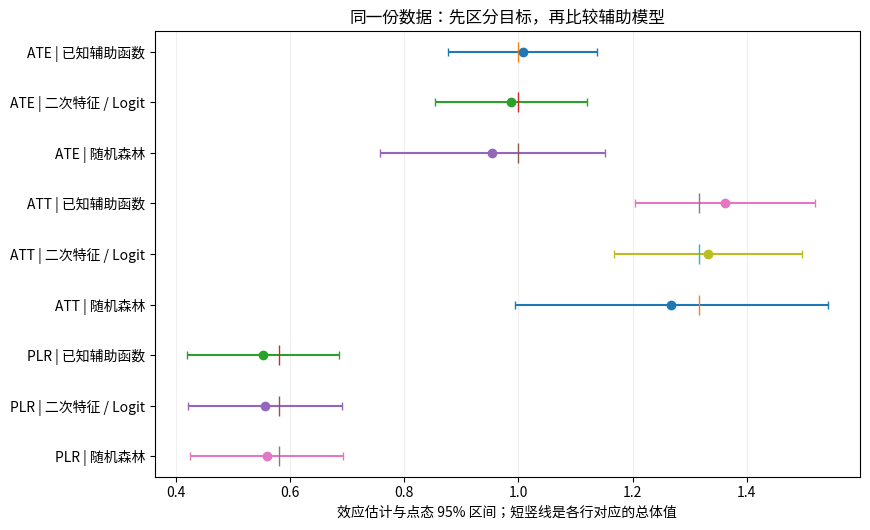

In [9]:
main_rows = []
result_sets = {"已知辅助函数": oracle_results, "二次特征 / Logit": fitted_results,
               "随机森林": forest_results}
for target in ["ATE", "ATT", "PLR"]:
    for label, results in result_sets.items():
        rr = results[target]
        main_rows.append({"目标": target, "辅助模型": label, "估计": rr["estimate"],
                          "标准误": rr["se"], "下限": rr["lower"], "上限": rr["upper"],
                          "对应总体值": pop_targets[target]})
main_table = pd.DataFrame(main_rows)
display(main_table.round(4))

fig, ax = plt.subplots(figsize=(8.8, 5.4))
for j, row in main_table.iterrows():
    ax.errorbar(row["估计"], j, xerr=Z_CRIT*row["标准误"], fmt="o", capsize=3)
    ax.plot(row["对应总体值"], j, marker="|", markersize=15, linestyle="none")
ax.set(yticks=np.arange(len(main_table)),
       yticklabels=[f"{r['目标']} | {r['辅助模型']}" for _, r in main_table.iterrows()],
       xlabel="效应估计与点态 95% 区间；短竖线是各行对应的总体值",
       title="同一份数据：先区分目标，再比较辅助模型")
ax.invert_yaxis()
ax.grid(axis="x", alpha=.2)
fig.tight_layout()
plt.show()

默认运行结果中，二次特征模型对 ATE、ATT、PLR 的估计约为 0.988、1.333、0.556，对应的总体目标为 1.000、1.316、0.581。随机森林在同一份数据上的 ATE、ATT 区间较宽。这个例子的结果函数恰好是二次的，不能据此给学习器排一个通用名次。

### 7. 同一份数据，分别改变两类辅助模型

为了与第八份衔接，再做一个小对照：将结果模型换成只有主效应的线性模型，或将评分换成每个训练折中的处理比例。后者依然是折外预测，但忽略了 $X$ 对处理分配的作用。

这个表只比较点估计，不给“一类持续错设”的组合套用刚才的简化 DML 标准误。单次结果接近真值也不能替代重复模拟或理论条件。

In [10]:
linear_oof = crossfit_irm(observed, *make_learners("linear"), splits)
constant_score = np.full(len(observed), np.nan)
for train, test in splits:
    constant_score[test] = t[train].mean()

spec_rows = []
for g_label, pr in [("二次结果", oof), ("线性结果", linear_oof)]:
    for e_label, ee in [("Logit评分", oof["e"]), ("常数评分", constant_score)]:
        rr = scores_from_predictions(y, t, pr["mu0"], pr["mu1"], ee)
        spec_rows.append({"结果模型": g_label, "评分模型": e_label,
                          "ATE点估计": rr["ATE"]["estimate"],
                          "ATT点估计": rr["ATT"]["estimate"]})
display(pd.DataFrame(spec_rows).round(4))

,结果模型,评分模型,ATE点估计,ATT点估计
0,二次结果,Logit评分,0.9875,1.3326
1,二次结果,常数评分,1.0002,1.3548
2,线性结果,Logit评分,1.0102,1.3517
3,线性结果,常数评分,0.9071,1.4521


## 软件核对：相同预测、相同得分、相同标准误

将相同数据、相同学习器与相同分折交给 `DoubleMLIRM`。明确关闭逆概率权重归一化，使用相同的 0.01 概率截断；不靠更换参数把两个结果凑到一起。[3–4]

不仅比较最后的系数，还逐项核对 $\widehat\mu_0$、$\widehat\mu_1$、评分、`psi_a`、`psi_b`、中心得分和标准误。软件把 ATT 写作 `score="ATTE"`。其中 $\mu_1$ 虽然由接口一并拟合，但在未归一化的 ATT 得分中代数消掉，并不是 ATT 必需的辅助函数。

In [11]:
def check_doubleml(data: pd.DataFrame, kind: str, manual_predictions: dict,
                   manual_results: dict, splits: list, clip: float = CLIP) -> pd.DataFrame:
    dml_data = dml.DoubleMLData(data, y_col="Y", d_cols="T", x_cols=X_COLS)
    comparisons = []
    for target, score_name in [("ATE", "ATE"), ("ATT", "ATTE")]:
        ml_g, ml_m = make_learners(kind)
        model = dml.DoubleMLIRM(
            dml_data, ml_g=ml_g, ml_m=ml_m, n_folds=len(splits), n_rep=1,
            score=score_name, normalize_ipw=False, draw_sample_splitting=False,
            ps_processor_config=PSProcessorConfig(clipping_threshold=clip),
        )
        model.set_sample_splitting(splits)
        model.fit(n_jobs_cv=1)
        pairs = {
            "mu0": (model.predictions["ml_g0"][:, 0, 0], manual_predictions["mu0"]),
            "mu1": (model.predictions["ml_g1"][:, 0, 0], manual_predictions["mu1"]),
            "评分": (model.predictions["ml_m"][:, 0, 0], manual_predictions["e"]),
            "psi_a": (model.psi_elements["psi_a"][:, 0, 0], manual_results[target]["a"]),
            "psi_b": (model.psi_elements["psi_b"][:, 0, 0], manual_results[target]["b"]),
            "中心得分": (model.psi[:, 0, 0], manual_results[target]["psi"]),
            "系数": (model.coef[0], manual_results[target]["estimate"]),
            "标准误": (model.se[0], manual_results[target]["se"]),
        }
        for name, (a, b) in pairs.items():
            np.testing.assert_allclose(a, b, rtol=1e-9, atol=1e-10,
                                       err_msg=f"{kind} {target} {name} 不一致")
            comparisons.append({"模型": kind, "目标": target, "核对量": name,
                                "最大绝对差": float(np.max(np.abs(np.asarray(a)-b)))})
    return pd.DataFrame(comparisons)


package_checks = pd.concat([
    check_doubleml(observed, "quadratic", oof, fitted_results, splits),
    check_doubleml(observed, "forest", forest_oof, forest_results, splits),
], ignore_index=True)
display(package_checks.groupby(["模型", "目标"])["最大绝对差"].max().to_frame())
print(f"DoubleML {dml.__version__}：{len(package_checks)} 项逐量核对通过。")

最大绝对差
模型        目标               
forest    ATE  2.842171e-14
          ATT  5.684342e-14
quadratic ATE  7.105427e-15
          ATT  7.105427e-15

DoubleML 0.11.4：32 项逐量核对通过。


## 模型分析

### 1. 重新生成数据，检查抽样误差与区间

一次估计落在真值附近还不够。下面每次重新生成 $X$、处理与结局，重新分折、重新拟合。两种样本量下分别比较“已知辅助函数”和“二次特征 / Logit 交叉拟合”。为了控制运行时间，不在每一次重复里训练随机森林。

每个估计都与自己的总体目标比较：ATE 为 1，ATT 与 PLR 使用前面的确定性积分值。不能把每次实际抽到的接受者平均效应，当成固定总体 ATT 来检查覆盖率。

表中同时给出经验标准差、平均得分标准误、RMSE 和覆盖率。后者本身有 Monte Carlo 误差，估计为 $\sqrt{\widehat c(1-\widehat c)/R}$，$R$ 是独立重复次数。这与单份研究里效应估计的标准误不是同一个量。

In [12]:
mc_rows, plugin_rows = [], []
for n in SAMPLE_SIZES:
    rng = np.random.default_rng(SEED_REPEAT+n)
    for repeat in range(N_REPEATS):
        data_seed, split_seed = rng.integers(0, 2**31-1, size=2).tolist()
        data_r, truth_r = make_irm_data(n, data_seed)
        _, t_r, y_r = check_data(data_r)
        splits_r = make_splits(t_r, seed=split_seed)
        cf_r = crossfit_irm(data_r, *make_learners("quadratic"), splits_r)
        reference = scores_from_predictions(y_r, t_r, truth_r["mu0"], truth_r["mu1"], truth_r["e"])
        learned = scores_from_predictions(y_r, t_r, cf_r["mu0"], cf_r["mu1"], cf_r["e"])
        for label, result in [("已知辅助函数", reference), ("交叉拟合", learned)]:
            for target, rr in result.items():
                actual = pop_targets[target]
                mc_rows.append({"n": n, "重复": repeat, "模型": label, "目标": target,
                                "估计": rr["estimate"], "误差": rr["estimate"]-actual,
                                "标准误": rr["se"],
                                "覆盖": rr["lower"] <= actual <= rr["upper"],
                                "截断行数": cf_r["n_clipped"] if label == "交叉拟合" else 0})
        plugin_rows.append({"n": n, "重复": repeat,
                            "仅预测差": float(np.mean(cf_r["mu1"]-cf_r["mu0"])),
                            "AIPW": learned["ATE"]["estimate"]})
mc = pd.DataFrame(mc_rows)
plugin_mc = pd.DataFrame(plugin_rows)

summary_rows = []
for (n, target, label), group in mc.groupby(["n", "目标", "模型"], sort=False):
    coverage = group["覆盖"].mean()
    summary_rows.append({"n": n, "目标": target, "模型": label,
                         "偏差": group["误差"].mean(),
                         "经验SD": group["估计"].std(ddof=1),
                         "平均SE": group["标准误"].mean(),
                         "RMSE": np.sqrt(np.mean(group["误差"]**2)),
                         "覆盖率": coverage,
                         "覆盖率MC_SE": np.sqrt(coverage*(1-coverage)/len(group))})
mc_summary = pd.DataFrame(summary_rows)
display(mc_summary.round(4))
print(f"共重新生成 {len(SAMPLE_SIZES)*N_REPEATS} 份独立数据；不是同一份数据反复分折。")
print("交叉拟合下发生任何评分截断的数据份数：")
display(mc.query("模型 == '交叉拟合' and 目标 == 'ATE'")
        .groupby("n")["截断行数"].apply(lambda v: int((v > 0).sum())).to_frame("份数"))

,n,目标,模型,偏差,经验SD,平均SE,RMSE,覆盖率,覆盖率MC_SE
0,600,ATE,已知辅助函数,-0.0023,0.1454,0.1370,0.1452,0.9367,0.0141
1,600,ATT,已知辅助函数,-0.0061,0.1779,0.1674,0.1777,0.9533,0.0122
2,600,PLR,已知辅助函数,0.0022,0.1391,0.1340,0.1389,0.9367,0.0141
3,600,ATE,交叉拟合,-0.0002,0.1563,0.1559,0.1561,0.9433,0.0133
4,600,ATT,交叉拟合,-0.0010,0.2020,0.1982,0.2017,0.9467,0.0130
5,600,PLR,交叉拟合,0.0010,0.1399,0.1358,0.1397,0.9433,0.0133
6,2400,ATE,已知辅助函数,0.0076,0.0699,0.0686,0.0702,0.9533,0.0122
7,2400,ATT,已知辅助函数,0.0084,0.0851,0.0836,0.0853,0.9500,0.0126
8,2400,PLR,已知辅助函数,0.0075,0.0687,0.0674,0.0690,0.9433,0.0133
9,2400,ATE,交叉拟合,0.0069,0.0718,0.0706,0.0720,0.9433,0.0133


共重新生成 600 份独立数据；不是同一份数据反复分折。
交叉拟合下发生任何评分截断的数据份数：


,份数
n,
600,0
2400,0


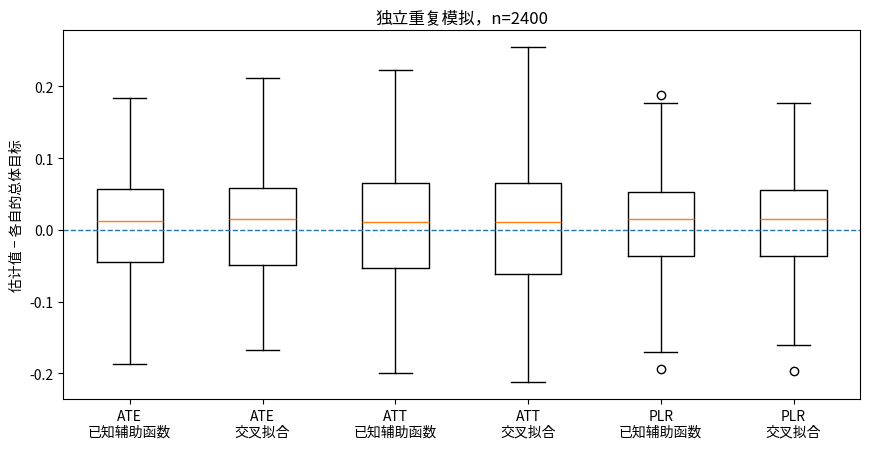

In [13]:
fig, ax = plt.subplots(figsize=(8.8, 4.6))
box_values, box_labels = [], []
for target in ["ATE", "ATT", "PLR"]:
    for label in ["已知辅助函数", "交叉拟合"]:
        part = mc[(mc["n"] == max(SAMPLE_SIZES)) & (mc["目标"] == target) & (mc["模型"] == label)]
        box_values.append(part["误差"].to_numpy())
        box_labels.append(f"{target}\n{label}")
ax.boxplot(box_values, tick_labels=box_labels, showfliers=True)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set(ylabel="估计值 − 各自的总体目标", title=f"独立重复模拟，n={max(SAMPLE_SIZES)}")
fig.tight_layout()
plt.show()

误差图把三个目标各自减掉后放在同一尺度上。这样才不会把 PLR 与 ATE 的目标差异，混进 PLR 的估计误差。

下面画覆盖率。误差棒只表示本次有限次数模拟对覆盖率的 Monte Carlo 近似误差；0.95 是参照线，不是程序必须达到的通过阈值。

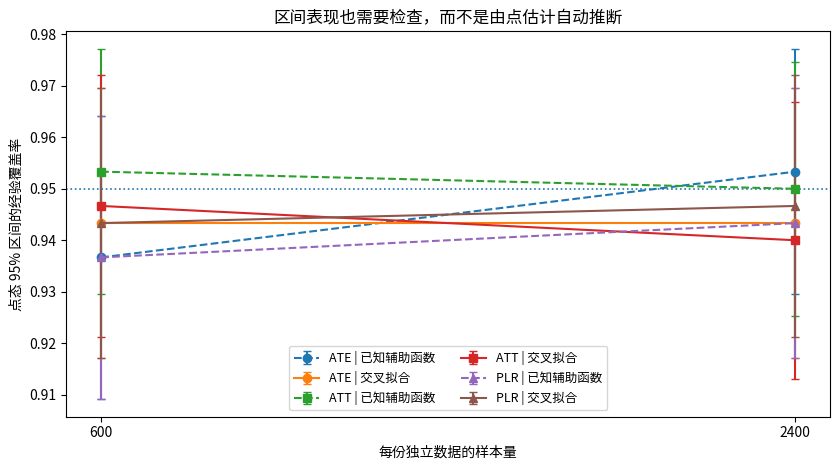

,n,ATE方法,偏差,经验SD,RMSE
0,600,仅预测差,0.0002,0.1475,0.1473
1,600,AIPW,-0.0002,0.1563,0.1561
2,2400,仅预测差,0.0098,0.0700,0.0706
3,2400,AIPW,0.0069,0.0718,0.0720


In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for target, marker in [("ATE", "o"), ("ATT", "s"), ("PLR", "^")]:
    for label, linestyle in [("已知辅助函数", "--"), ("交叉拟合", "-")]:
        part = mc_summary[(mc_summary["目标"] == target) & (mc_summary["模型"] == label)].sort_values("n")
        ax.errorbar(part["n"], part["覆盖率"], yerr=Z_CRIT*part["覆盖率MC_SE"],
                    marker=marker, linestyle=linestyle, capsize=3, label=f"{target} | {label}")
ax.axhline(.95, linestyle=":", linewidth=1.2)
ax.set(xlabel="每份独立数据的样本量", ylabel="点态 95% 区间的经验覆盖率",
       title="区间表现也需要检查，而不是由点估计自动推断", xticks=list(SAMPLE_SIZES))
ax.legend(ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

plugin_summary = []
for n, group in plugin_mc.groupby("n"):
    for method in ["仅预测差", "AIPW"]:
        err = group[method]-pop_targets["ATE"]
        plugin_summary.append({"n": n, "ATE方法": method, "偏差": err.mean(),
                               "经验SD": group[method].std(ddof=1),
                               "RMSE": np.sqrt(np.mean(err**2))})
display(pd.DataFrame(plugin_summary).round(4))

默认设置中，交叉拟合 ATE 在两个样本量下的覆盖率均为 0.943；ATT 分别为 0.947、0.940，PLR 分别为 0.943、0.947。300 次重复下，覆盖率的 Monte Carlo 标准误约为 0.013，不宜把一两百分点的差异解读为方法优劣。平均得分标准误与经验标准差大致相近；样本量从 600 增至 2,400 时，二者都明显减小。

这个生成式的结果模型相对容易学，直接平均预测差也可能有很好的有限样本表现。AIPW 的意义不在于每次都比它有更小的 RMSE，而在于得分的偏差结构与相应的推断性质。反过来，采用正交得分也不保证每种样本量、每种学习器都恰好有 95% 覆盖率。

### 2. 有了交叉拟合，低重叠还会不会放大噪声？

把处理概率改为

$$
e_s(X)=\operatorname{expit}\{0.8+s(2X_1+0.6X_2)\}.
$$

从 $s=1$ 改为 $s=3$ 后，某些人的处理几乎确定。结果生成式不变，因此总体 ATE 仍为 1；ATT 与 PLR 的加权目标会随处理机制改变，本节只比较 ATE。

为了单独观察重叠，而不掺入拟合误差，这次直接使用真实的 $e,\mu_0,\mu_1$。如果连已知辅助函数时都出现很大的加权残差，就不能把问题全归咎于学习器，也不能认为交叉拟合会把它消掉。[2，备注 9.3.2]

但单份样本可能恰好没有抽到“很少发生、权重很大”的观测。因此看完这份样本，再为两种机制各生成 500 份独立数据。由已知辅助函数的 ATE 得分，按条件方差分解可得到本例的直接计算补充：

$$
\operatorname{Var}(\Gamma)
=\operatorname{Var}\{\tau(X)\}
+E\left[\frac{\sigma_1^2(X)}{e(X)}+\frac{\sigma_0^2(X)}{1-e(X)}\right].
$$

这里 $\sigma_t(X)$ 是生成式中第 $t$ 侧噪声的标准差。将这个方差除以样本量再开方，可以核对已知辅助函数 ATE 估计的理论标准差；它不是依靠当前那一份样本的尾部观测来计算的。

,ATE估计,得分SE,处理ESS,对照ESS,最大绝对影响值,最大1%行的方差份额
s,,,,,,
1.0,1.0371,0.0828,832.2328,332.1011,40.4627,0.3747
3.0,0.9453,0.0922,360.9138,100.9455,58.7508,0.6166


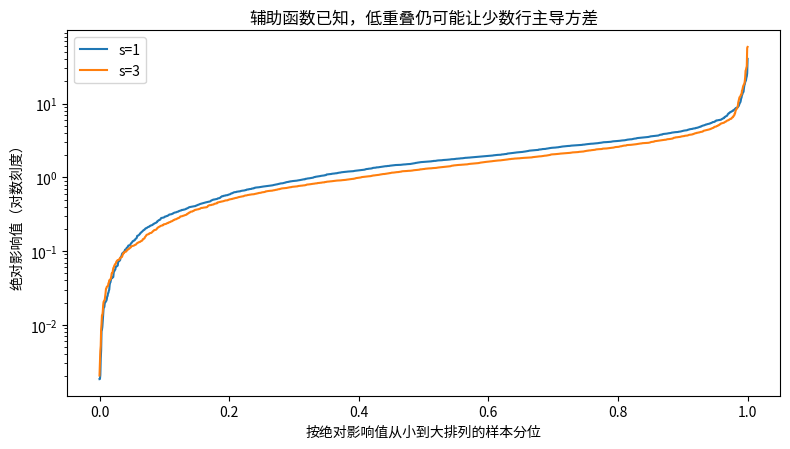

,偏差,理论SD,经验SD,平均得分SE,最大绝对误差,覆盖率
s,,,,,,
1.0,0.0038,0.0842,0.0847,0.0840,0.2839,0.948
3.0,-0.0097,0.3721,0.3123,0.2387,1.9892,0.966


In [15]:
overlap_runs, overlap_rows = {}, []
for scale in [1., 3.]:
    data_s, truth_s = make_irm_data(N_OVERLAP, SEED_OVERLAP, overlap_scale=scale)
    _, t_s, y_s = check_data(data_s)
    rr = scores_from_predictions(y_s, t_s, truth_s["mu0"], truth_s["mu1"], truth_s["e"])["ATE"]
    influence_abs = np.abs(rr["influence"])
    k_top = max(1, int(np.ceil(.01*len(data_s))))
    fraction_top = (np.sort(influence_abs**2)[-k_top:].sum() / np.sum(influence_abs**2))
    w1, w0 = t_s/truth_s["e"], (1-t_s)/(1-truth_s["e"])
    overlap_rows.append({"s": scale, "ATE估计": rr["estimate"], "得分SE": rr["se"],
                         "处理ESS": effective_n(w1), "对照ESS": effective_n(w0),
                         "最大绝对影响值": influence_abs.max(),
                         "最大1%行的方差份额": fraction_top})
    overlap_runs[scale] = (data_s, truth_s, rr)
display(pd.DataFrame(overlap_rows).set_index("s").round(4))

fig, ax = plt.subplots(figsize=(8, 4.6))
for scale, (_, _, rr) in overlap_runs.items():
    sorted_values = np.sort(np.abs(rr["influence"]))
    ax.plot(np.linspace(0, 1, len(sorted_values)), sorted_values, label=f"s={scale:g}")
ax.set(yscale="log", xlabel="按绝对影响值从小到大排列的样本分位",
       ylabel="绝对影响值（对数刻度）", title="辅助函数已知，低重叠仍可能让少数行主导方差")
ax.legend()
fig.tight_layout()
plt.show()


def oracle_ate_variance(scale: float, order: int = 120) -> float:
    nodes, weights = leggauss(order)
    xx1, xx2 = np.meshgrid(nodes, nodes, indexing="ij")
    ww = weights[:, None]*weights[None, :]/4
    ee = expit(.8+scale*(2*xx1+.6*xx2))
    variance_tau = 1.8**2/3+2.4**2*(1/5-1/9)+.5**2/9
    noise_term = np.sum(ww*((1+.4*np.abs(xx2))**2/ee
                           +(1+.25*np.abs(xx1))**2/(1-ee)))
    return float(variance_tau+noise_term)


overlap_mc_rows = []
for scale in [1., 3.]:
    estimates_s, standard_errors_s, covers_s = [], [], []
    for repeat in range(N_OVERLAP_REPEATS):
        dd, tt = make_irm_data(N_OVERLAP, SEED_OVERLAP+10000+repeat, overlap_scale=scale)
        yy, tr = dd["Y"].to_numpy(), dd["T"].to_numpy()
        result = scores_from_predictions(yy, tr, tt["mu0"], tt["mu1"], tt["e"])["ATE"]
        estimates_s.append(result["estimate"])
        standard_errors_s.append(result["se"])
        covers_s.append(result["lower"] <= 1 <= result["upper"])
    overlap_mc_rows.append({"s": scale, "偏差": np.mean(estimates_s)-1,
                            "理论SD": np.sqrt(oracle_ate_variance(scale)/N_OVERLAP),
                            "经验SD": np.std(estimates_s, ddof=1),
                            "平均得分SE": np.mean(standard_errors_s),
                            "最大绝对误差": np.max(np.abs(np.asarray(estimates_s)-1)),
                            "覆盖率": np.mean(covers_s)})
overlap_mc_summary = pd.DataFrame(overlap_mc_rows).set_index("s")
display(overlap_mc_summary.round(4))

低重叠机制下，理论标准差比常规机制大得多。单份样本的得分标准误却未必按同样幅度增加；稀有大权重观测是否出现，会影响估计和方差表现。表中保留实际覆盖率，不把低重叠一概等同于本次区间一定失败，也不以一次没有出现极端值来判断问题已经解决。

### 3. 限制评分，不等于恢复了重叠

主程序把评分限制在 $[c,1-c]$，并单独报告被改动的行。这里是 clipping，不是删除样本的 trimming；原书备注 9.3.2 使用 trimming 一词讨论限制逆概率项的做法。二者不能只看名称就混用。

在本节的固定辅助函数实验中，若结果均值完全正确，加权残差的条件期望仍为零，因此换成截断评分不会改变 AIPW 的总体均值。但它会影响方差；更重要的是，评分被系统改写之后，结果模型误差不再总能由真实评分抵消。

用一个可以直接计算总体偏差的反例看这个区别：将两侧结果预测都加上 0.8。两条曲线的差没有变，但单侧均值都错了。真实评分仍能纠偏；截断后的评分则可能留下偏差。下面按前面的乘积公式积分，不把一张随机样本的偏移当成总体偏差。

,阈值c,改变评分的行数,结果均值已知_估计,两侧偏移0.8_估计,两侧偏移0.8_总体偏差
0,0.001,39,0.9453,0.9816,-0.0103
1,0.005,259,0.9453,0.9813,-0.0475
2,0.010,420,0.9451,0.9808,-0.0670
3,0.025,649,0.9446,0.9454,-0.0900
4,0.050,821,0.9251,0.8854,-0.1023
5,0.100,1014,0.9474,0.8616,-0.1132


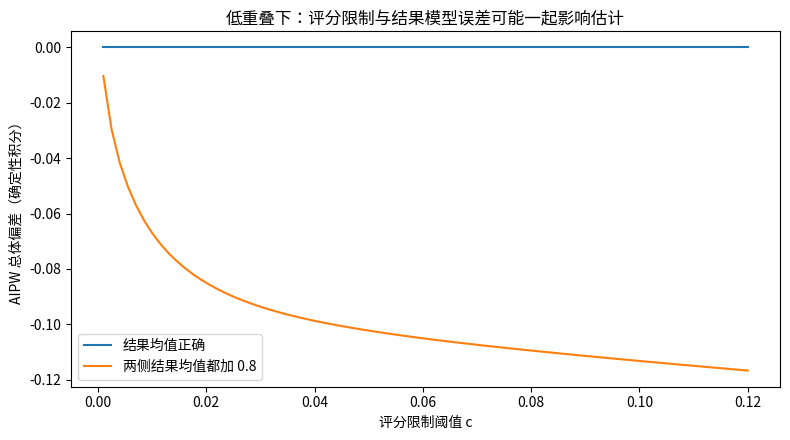

In [16]:
def clipping_bias(clip: float, shift: float, scale: float = 3., order: int = 120) -> float:
    if not 0 < clip < .5 or not np.isfinite(shift):
        raise ValueError("需要 0 < clip < .5，且 shift 有限。")
    nodes, weights = leggauss(order)
    x1, x2 = np.meshgrid(nodes, nodes, indexing="ij")
    w = weights[:, None]*weights[None, :]/4
    e_true = expit(.8+scale*(2*x1+.6*x2))
    e_clipped = np.clip(e_true, clip, 1-clip)
    # a1=a0=shift；对应理论基础中的 E[b(a1/e_hat+a0/(1-e_hat))]。
    return float(np.sum(w*(e_clipped-e_true)*(shift/e_clipped+shift/(1-e_clipped))))


data_low, truth_low, _ = overlap_runs[3.]
_, t_low, y_low = check_data(data_low)
clip_levels = [.001, .005, .01, .025, .05, .1]
clip_rows = []
for cutoff in clip_levels:
    e_clipped = np.clip(truth_low["e"], cutoff, 1-cutoff)
    rr_true = scores_from_predictions(y_low, t_low, truth_low["mu0"], truth_low["mu1"], e_clipped)["ATE"]
    rr_shift = scores_from_predictions(y_low, t_low, truth_low["mu0"]+.8, truth_low["mu1"]+.8, e_clipped)["ATE"]
    clip_rows.append({"阈值c": cutoff,
                      "改变评分的行数": int(np.sum(e_clipped != truth_low["e"])),
                      "结果均值已知_估计": rr_true["estimate"],
                      "两侧偏移0.8_估计": rr_shift["estimate"],
                      "两侧偏移0.8_总体偏差": clipping_bias(cutoff, .8)})
display(pd.DataFrame(clip_rows).round(4))

clip_grid = np.linspace(.001, .12, 80)
fig, ax = plt.subplots(figsize=(8, 4.5))
for shift in [0., .8]:
    curve = [clipping_bias(c, shift) for c in clip_grid]
    ax.plot(clip_grid, curve, label="结果均值正确" if shift == 0 else "两侧结果均值都加 0.8")
ax.set(xlabel="评分限制阈值 c", ylabel="AIPW 总体偏差（确定性积分）",
       title="低重叠下：评分限制与结果模型误差可能一起影响估计")
ax.legend()
fig.tight_layout()
plt.show()

表中的单次估计含抽样噪声，而总体偏差列描述固定辅助函数下的期望偏移。不能以某一次更接近 1 来选择阈值。

上图没有删除任何人，因此不把截断结果另称为“修剪人群 ATE”。同时，也不能仅因为目标仍写着总体 ATE，就保证估计仍然一致。

在主分析里，0.01 是透明的教学设置，不是通用最优值。遇到真实数据，应报告处理组人数、评分分布、修改比例、权重集中和结果对设置的敏感程度；严重缺乏可比较人群时，需要重新考虑目标，而不是不断调整阈值直到出现满意结果。

## 练习

### 练习一：只取接受者的 ATE 伪结局，能得到 ATT 吗？

先回到三层总体表，展开成六行：每类人分别有 $T=0,1$ 两种观测状态，概率为 $p_x(1-e_x)$ 与 $p_xe_x$。暂不加入结局噪声，逐行计算后按联合概率求平均。

保持评分与 $\mu_0$ 正确，将 $\widehat\mu_1$ 分别设为正确值、正确值加 1。比较完整 ATE、正确的 ATT 得分，以及“只取 $T=1$ 行的 ATE 伪结局平均”。

<details>
<summary>思路：为什么第三种平均不再具有同样的稳健性？</summary>

当三项辅助函数都正确时，$E[\Gamma\mid T=1]=\theta_T$；问题不是任何情况下都不能平均，而是这个做法一般不是 ATT 的正交、双重稳健构造。令 $\widehat\mu_1=\mu_1+c$，评分与 $\mu_0$ 保持正确，则在接受者中

$$
E[\widehat\Gamma\mid T=1]
=\theta_T+c\,E[1-1/e(X)\mid T=1]
=\theta_T+c(1-1/p).
$$

整体 ATE 里由另一组提供的抵消，筛掉对照后不见了。正确的 ATT 得分本来就不依赖 $\mu_1$，因此不受这个扰动影响。

</details>

In [17]:
joint_rows = []
for _, row in population.iterrows():
    for state in [0, 1]:
        ee = row["处理概率"]
        joint_rows.append({"类别": row["类别"], "T": state,
                           "概率": row["总体比例"]*(ee if state else 1-ee),
                           "Y": row["mu1"] if state else row["mu0"],
                           "e": ee, "mu0": row["mu0"], "mu1": row["mu1"]})
joint = pd.DataFrame(joint_rows)
display(joint.round(4))
w = joint["概率"].to_numpy()
tj, yj, ej = [joint[name].to_numpy() for name in ["T", "Y", "e"]]
g0j, g1j = joint["mu0"].to_numpy(), joint["mu1"].to_numpy()
pj = np.sum(w*tj)
exercise_one = []
for shift in [0., 1.]:
    g1_work = g1j+shift
    gamma = g1_work-g0j+tj/ej*(yj-g1_work)-(1-tj)/(1-ej)*(yj-g0j)
    att_num = tj*(yj-g0j)-(1-tj)*ej/(1-ej)*(yj-g0j)
    ate_value = float(w @ gamma)
    att_value = float(w @ att_num/pj)
    restricted_value = float((w*tj) @ gamma/pj)
    np.testing.assert_allclose(ate_value, toy_targets["ATE"])
    np.testing.assert_allclose(att_value, toy_targets["ATT"])
    np.testing.assert_allclose(restricted_value, toy_targets["ATT"]+shift*(1-1/pj))
    exercise_one.append({"mu1增加量": shift, "总体ATE": ate_value,
                         "正确ATT": att_value, "只平均接受者Gamma": restricted_value})
display(pd.DataFrame(exercise_one).round(4))

,类别,T,概率,Y,e,mu0,mu1
0,A,0,0.32,2.0,0.2,2.0,2.5
1,A,1,0.08,2.5,0.2,2.0,2.5
2,B,0,0.15,3.0,0.5,3.0,4.0
3,B,1,0.15,4.0,0.5,3.0,4.0
4,C,0,0.03,4.0,0.9,4.0,7.0
5,C,1,0.27,7.0,0.9,4.0,7.0


,mu1增加量,总体ATE,正确ATT,只平均接受者Gamma
0,0.0,1.4,2.0,2.0
1,1.0,1.4,2.0,1.0


### 练习二：结局改成 0/1，应该传入类别还是概率？

保持主案例的 $X$ 与处理分配，另生成一个二元结局。指定两种处理下的风险

$$
q_0(X)=\operatorname{expit}(-1+0.8X_1+0.6X_2^2),
\qquad
q_1(X)=\operatorname{expit}(-1+0.8X_1+0.6X_2^2+0.4+0.8X_1).
$$

用两组 Logistic 回归估计风险，再使用相同的交叉拟合 AIPW。这里的 ATE 是平均风险差，不是 Logistic 回归系数，也不是平均个体赔率比。

<details>
<summary>思路：为什么不能先把概率切成 0/1？</summary>

二元 $Y$ 的条件均值就是条件概率。结果分类器和评分分类器都应该输出类别 1 的概率。本篇的 `predict_mean` 会检查分类器类别并调用 `predict_proba`；这是软件接口补充，见 [3]。

$\widehat q_t$ 必须在 $[0,1]$ 内，但 AIPW 加上残差纠偏后的逐行量可以超出该区间。不要把这些逐行量重新截到 $[0,1]$，否则又改变了得分。风险差区间也只是渐近区间，不强行保证端点落在 $[-1,1]$。

</details>

,估计,标准误,下限,上限,总体值
量,,,,,
全体不处理时的风险,0.3021,0.0254,0.2524,0.3518,0.3193
全体处理时的风险,0.4195,0.0130,0.3941,0.4449,0.4179
ATE：平均风险差,0.1174,0.0283,0.0620,0.1728,0.0986


两侧风险预测的范围： (0.0374, 0.8277, 0.0512, 0.9231)
ATE 逐行 Gamma 的范围：[-12.126, 16.175]


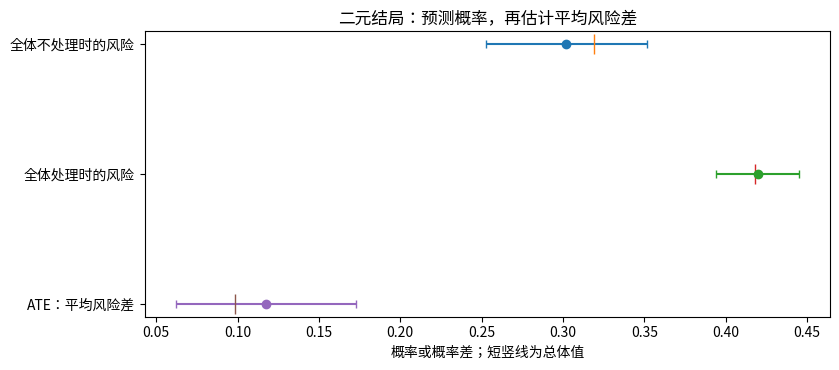

In [18]:
binary_data = observed.copy()
risk0 = expit(-1+.8*x[:, 0]+.6*x[:, 1]**2)
risk1 = expit(-1+.8*x[:, 0]+.6*x[:, 1]**2+.4+.8*x[:, 0])
rng_binary = np.random.default_rng(SEED_BINARY)
binary_data["Y"] = rng_binary.binomial(1, np.where(t == 1, risk1, risk0))
yb = binary_data["Y"].to_numpy(dtype=float)

risk_learner = make_pipeline(PolynomialFeatures(degree=2, include_bias=False),
                            StandardScaler(), LogisticRegression(C=1., max_iter=1000, tol=1e-8))
_, treatment_learner = make_learners("quadratic")
binary_oof = crossfit_irm(binary_data, risk_learner, treatment_learner, splits)
binary_results = scores_from_predictions(yb, t, binary_oof["mu0"], binary_oof["mu1"], binary_oof["e"])

# 均值真值用二维积分，不用观测组间比例代替。
zq, wq = leggauss(100)
xq1, xq2 = np.meshgrid(zq, zq, indexing="ij")
wwq = wq[:, None]*wq[None, :]/4
q0 = expit(-1+.8*xq1+.6*xq2**2)
q1 = expit(-1+.8*xq1+.6*xq2**2+.4+.8*xq1)
mean_q0, mean_q1 = float(np.sum(wwq*q0)), float(np.sum(wwq*q1))

gamma0 = binary_oof["mu0"]+(1-t)/(1-binary_oof["e"])*(yb-binary_oof["mu0"])
gamma1 = binary_oof["mu1"]+t/binary_oof["e"]*(yb-binary_oof["mu1"])
risk_results = {
    "全体不处理时的风险": (linear_score(-np.ones(len(t)), gamma0), mean_q0),
    "全体处理时的风险": (linear_score(-np.ones(len(t)), gamma1), mean_q1),
    "ATE：平均风险差": (binary_results["ATE"], mean_q1-mean_q0),
}
risk_rows = [{"量": label, "估计": rr["estimate"], "标准误": rr["se"],
              "下限": rr["lower"], "上限": rr["upper"], "总体值": actual}
             for label, (rr, actual) in risk_results.items()]
display(pd.DataFrame(risk_rows).set_index("量").round(4))
print("两侧风险预测的范围：",
      tuple(float(v) for v in np.round([binary_oof['mu0'].min(), binary_oof['mu0'].max(),
                      binary_oof['mu1'].min(), binary_oof['mu1'].max()], 4)))
print(f"ATE 逐行 Gamma 的范围：[{(gamma1-gamma0).min():.3f}, {(gamma1-gamma0).max():.3f}]")

fig, ax = plt.subplots(figsize=(8.5, 3.8))
for j, (label, (rr, actual)) in enumerate(risk_results.items()):
    ax.errorbar(rr["estimate"], j, xerr=Z_CRIT*rr["se"], fmt="o", capsize=3)
    ax.plot(actual, j, marker="|", markersize=15, linestyle="none")
ax.set(yticks=np.arange(len(risk_results)), yticklabels=list(risk_results),
       xlabel="概率或概率差；短竖线为总体值", title="二元结局：预测概率，再估计平均风险差")
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## 总结与适用范围

这一篇从 AIPW 的公式接到了 DML 的运行流程：每个人拥有三列折外预测，再按目标构造得分。ATE 对全体平均；ATT 需要接受者的未处理反事实，得分与分母处理都不同；二元处理下的 PLR 通常对应重叠加权平均，并不会因为采用了机器学习就自动变成 ATE。

主案例中，二次特征模型利用了一个相对容易学习的条件均值结构。随机森林只是另一种辅助预测器，不是新的识别策略。得分均值为零、与软件一致、模拟表现合理，分别检查了计算、实现和有限样本性能；它们都不能替真实研究验证无未测混杂。

进入真实数据时，先固定处理、结局、目标人群与调整变量，再检查各训练折的两组人数、折外预测误差、评分与权重集中。报告效应时一起报告估计目标、分折方式、学习器、评分限制和区间构造。若要进一步研究“哪些特征对应更大的条件效应”，下一篇才开始训练与比较 CATE 元学习器。

## 参考资料

[1] Peng Ding. *A First Course in Causal Inference*. 本次使用上传的 arXiv:2305.18793v2（2023-10-03）版本，第 12 章、第 13.1–13.2 节。ATE 与 ATT 的双重稳健公式分别见定义 12.1 与定义 13.1。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传附件扉页为 2026-05-03，Version 0.1.2。主要阅读第 9.3 节、第 9.4 节的 IRM 与 ATET 得分，ATT 识别条件另见附录 5.C；PLR 的重叠加权解释见备注 9.3.3。书中 $D,m_0,g_0(t,X)$ 在本篇写作 $T,e,\mu_t$。

[3] DoubleML 官方文档：[DoubleMLIRM 接口](https://docs.doubleml.org/stable/api/generated/doubleml.irm.DoubleMLIRM.html)。仅作为软件接口补充，不替代两本书的方法学依据。本次实际核对版本为 0.11.4。

[4] DoubleML 官方文档：[Score functions — Binary Interactive Regression Model](https://docs.doubleml.org/stable/guide/scores.html#binary-interactive-regression-model-irm)。用于核对 `ATE`、`ATTE`、得分分量与权重归一化选项。软件页面核查日期为 2026-10-01；后续接口变化应以安装版本为准。